In [99]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import numpy as np
from torch import nn
from torch.nn import CrossEntropyLoss
from torch.optim import Adam
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [100]:
df = pd.read_parquet("../../data/processed/train.parquet")
df.head()

,features,label
0,"[[0.257080078125, 0.2939453125, 0.320068359375...",1
1,"[[0.2548828125, 0.301025390625, 0.3330078125, ...",3
2,"[[0.240966796875, 0.2900390625, 0.333984375, 0...",4
3,"[[0.1929931640625, 0.238037109375, 0.241943359...",5
4,"[[0.72314453125, 0.68212890625, 0.65576171875,...",6


In [101]:
df.iloc[0]['features']

array([array([0.25708008, 0.29394531, 0.32006836, 0.33007812, 0.3359375 ,
              0.24902344, 0.28100586, 0.30395508, 0.3190918 , 0.22900391,
              0.26098633, 0.28710938, 0.30493164, 0.2199707 , 0.24902344,
              0.27392578, 0.29199219, 0.2199707 , 0.24304199, 0.26391602,
              0.28100586, 0.67089844, 0.65283203, 0.62695312, 0.60693359,
              0.59179688, 0.60009766, 0.57617188, 0.56787109, 0.56591797,
              0.60009766, 0.57910156, 0.57080078, 0.56884766, 0.60302734,
              0.58300781, 0.57519531, 0.57177734, 0.60693359, 0.58789062,
              0.58007812, 0.57714844, 0.        , 0.        , 0.        ,
              0.        , 0.        , 0.        , 0.        , 0.        ,
              0.        , 0.        , 0.        , 0.        , 0.        ,
              0.        , 0.        , 0.        , 0.        , 0.        ,
              0.        , 0.        , 0.        , 0.        , 0.        ,
              0.        , 0.        , 

In [102]:
max_seq_len = 0
for row in df['features']:
    if len(row) > max_seq_len:
        max_seq_len = len(row)
print(f"Max sequence lenght: {max_seq_len}")

Max sequence lenght: 83


In [103]:
class LandmarkDataset(Dataset):
    def __init__(self, dataset_path: str, max_seq_len: int = None):
        self.df = pd.read_parquet(dataset_path)
        if max_seq_len is None:
            max_seq_len = 0
            for row in self.df['features']:
                if len(row) > max_seq_len:
                    max_seq_len = len(row)
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        features = self.df.iloc[idx]['features']
        label = self.df.iloc[idx]['label']
        
        tensors = [torch.from_numpy(a).float() for a in features]
        row_tensor = torch.stack(tensors)
        
        if len(row_tensor) < max_seq_len:
            pad_size = max_seq_len - len(row_tensor)
            padded = torch.cat([
                row_tensor, 
                torch.zeros(pad_size, 84)
            ], dim=0)
        elif len(row_tensor) > max_seq_len:
            padded = row_tensor[:max_seq_len]
        else:
            padded = row_tensor
        
        return padded, label    

In [104]:
train_dataset = LandmarkDataset("../../data/processed/train.parquet")
test_dataset = LandmarkDataset("../../data/processed/test.parquet")

train_size = int(len(train_dataset) * 0.8)
val_size = len(train_dataset) - train_size
    
train_dataset, val_dataset = random_split(
        train_dataset, [train_size, val_size]
)

train_loader = DataLoader(
        train_dataset,
        batch_size=16,
        shuffle=True,
)
    
val_loader = DataLoader(
        val_dataset,
        batch_size=16
)

test_loader = DataLoader(
        test_dataset,
        batch_size=16
)

In [105]:
def train(
    model,
    epochs,
    optimizer,
    loss_fn
):
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for features, labels in (pbar := tqdm(train_loader, desc=f"Epoch {epoch+1:3d}/{epochs} │ Training", leave=False)):
            optimizer.zero_grad()
            logits = model(features)
            loss = loss_fn(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * features.size(0)
            total_train += labels.size(0)
            
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == labels).sum().item()
            
            running_loss = train_loss / total_train
            pbar.set_postfix({"loss": f"{running_loss:.4f}"})

        model.eval()
        val_loss = 0.0
        total_val = 0
        correct_val = 0
        
        with torch.inference_mode():
            for features, labels in (pbar := tqdm(val_loader, desc=f"Epoch {epoch+1:3d}/{epochs} │ Validating", leave=False)):
                logits = model(features)
                loss = loss_fn(logits, labels)
                
                val_loss += loss.item() * features.size(0)
                total_val += labels.size(0)
                
                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == labels).sum().item()
                
                running_val_loss = val_loss / total_val
                pbar.set_postfix({"loss": f"{running_val_loss:.4f}"})
        
        avg_train_loss = train_loss / total_train
        avg_val_loss = val_loss / total_val
        
        train_acc = correct_train / total_train
        val_acc = correct_val / total_val
        
        print(
            f"Epoch {epoch+1:3d}/{epochs} │ "
            f"Train Loss: {avg_train_loss:.4f} │ Val Loss: {avg_val_loss:.4f} │ "
            f"Train Acc: {train_acc:.4f} │ Val Acc: {val_acc:.4f}"
        )

In [106]:
def test(
    model,
    loss_fn
):
    model.eval()
    test_loss = 0.0
    total_test = 0
    correct_test = 0
    
    all_preds = []
    all_labels = []
    
    with torch.inference_mode():
        for features, labels in (pbar := tqdm(val_loader, desc=f"Testing │", leave=False)):
            logits = model(features)
            loss = loss_fn(logits, labels)
            
            test_loss += loss.item() * features.size(0)
            total_test += labels.size(0)
            
            preds = torch.argmax(logits, dim=1)
            correct_test += (preds == labels).sum().item()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            running_test_loss = test_loss / total_test
            pbar.set_postfix({"loss": f"{running_test_loss:.4f}"})
    
    avg_test_loss = test_loss / total_test
    test_acc = correct_test / total_test
    
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        "test_loss": avg_test_loss,
        "test_acc": test_acc,
        "f1_score": f1,
        "confusion_matrix": cm
    }

In [107]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

In [108]:
class GestureTransformer(nn.Module):
    def __init__(
        self,
        num_classes: int = 33,
        d_model: int = 84,
        d_ff: int = 256,
        num_encoders: int = 3,
        nheads: int = 4, 
        dropout: float = 0.3 
    ):
        super().__init__()
        
        # Input projection
        self.input_proj = nn.Linear(84, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Transformer encoder only
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nheads,
            dim_feedforward=d_ff,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_encoders
        )
        
        # Classifier
        self.fc = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Input projection
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = self.pos_encoding(x)
        
        # Add CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)  # (batch, seq_len+1, d_model)
        
        # Transformer encoder
        encoded = self.transformer(x)  # (batch, seq_len+1, d_model)
        
        # Use CLS token for classification
        cls_output = encoded[:, 0, :]  # (batch, d_model)
        
        # Classification
        logits = self.fc(cls_output)  # (batch, num_classes)
        return logits

In [109]:
class GestureRNN(nn.Module):
    def __init__(
        self,
        num_classes: int = 33,
        d_model: int = 84,
        d_hidden: int = 128,
        num_layers: int = 3,
        dropout: float = 0.3
    ):
        super().__init__()  
        
        self.input_proj = nn.Linear(84, d_model)
        
        self.gru = nn.GRU(
            input_size=d_model,
            hidden_size=d_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(d_hidden, num_classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Input: (batch_size, seq_len, 84)
        x = self.input_proj(x)  # (batch_size, seq_len, d_model)
        
        # GRU forward
        output, hidden = self.gru(x)  # output: (batch_size, seq_len, d_hidden)
        
        # Use the last output of the sequence
        last_output = output[:, -1, :]  # (batch_size, d_hidden) - last timestep
        
        # Apply dropout and classify
        last_output = self.dropout(last_output)
        logits = self.fc(last_output)  # (batch_size, num_classes)
        
        return logits

In [110]:
class GestureCNN(nn.Module):
    def __init__(
        self,
        num_classes: int = 33,
        d_model: int = 84,
        d_hidden: int = 256,
        dropout: float = 0.3
    ):
        super().__init__()

        self.input_proj = nn.Linear(84, d_model)  
        
        # Convolution layers
        self.convs = nn.Sequential(
            # After input_proj: (batch, seq_len, d_model)  transpose  (batch, d_model, seq_len)
            nn.Conv1d(d_model, d_hidden, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),  # seq_len: 100 → 50
            
            nn.Conv1d(d_hidden, d_hidden * 2, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),  # seq_len: 50 → 25
            
            nn.Conv1d(d_hidden * 2, d_hidden * 4, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # (batch, d_hidden*4, 1)
        )   
        
        # Classifier - input size must match last conv layer output channels
        self.fc = nn.Linear(d_hidden * 4, num_classes)   
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len=100, features=84)
        x = self.input_proj(x)  # (batch_size, 100, d_model)
        x = x.transpose(1, 2)   # (batch_size, d_model, 100)
        
        x = self.convs(x)       # (batch_size, d_hidden*4, 1)
        x = x.squeeze(-1)       # (batch_size, d_hidden*4)
        
        x = self.dropout(x)
        x = self.fc(x)          # (batch_size, num_classes)
        return x

Transformer
torch.Size([16, 33])


Epoch   1/10 │ Train Loss: 3.5090 │ Val Loss: 3.4799 │ Train Acc: 0.0297 │ Val Acc: 0.0361


Epoch   2/10 │ Train Loss: 3.4654 │ Val Loss: 3.4413 │ Train Acc: 0.0419 │ Val Acc: 0.0569


Epoch   3/10 │ Train Loss: 3.4438 │ Val Loss: 3.4047 │ Train Acc: 0.0513 │ Val Acc: 0.0489


Epoch   4/10 │ Train Loss: 3.4166 │ Val Loss: 3.3660 │ Train Acc: 0.0547 │ Val Acc: 0.0817


...

Epoch   7/10 │ Train Loss: 3.0681 │ Val Loss: 2.9171 │ Train Acc: 0.1102 │ Val Acc: 0.1266


Epoch   8/10 │ Train Loss: 2.9645 │ Val Loss: 2.8377 │ Train Acc: 0.1189 │ Val Acc: 0.1114


Epoch   9/10 │ Train Loss: 2.9084 │ Val Loss: 2.8043 │ Train Acc: 0.1263 │ Val Acc: 0.1506


Epoch  10/10 │ Train Loss: 2.8551 │ Val Loss: 2.7885 │ Train Acc: 0.1353 │ Val Acc: 0.1162


Testing loss:		2.788546180113768
Testing accuracy:	0.11618589743589744
Testing F1:	0.07614429277919661


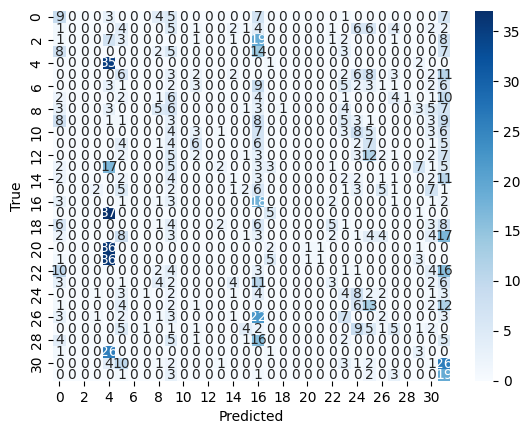

In [ ]:
print("Transformer")
model = GestureTransformer(
    num_classes=33,
    d_model=32,
    d_ff=32,
    num_encoders=2,
    nheads=2,
    dropout=0.3
)

optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = CrossEntropyLoss()

example_input = torch.randn(16, 12, 84)
logits = model(example_input)

print(logits.shape)
train(
    model=model,
    epochs=10,
    optimizer=optimizer,
    loss_fn=loss_fn
)

testing_results = test(  
    model=model,
    loss_fn=loss_fn
)

print(f"Testing loss:\t\t{testing_results["test_loss"]}")
print(f"Testing accuracy:\t{testing_results["test_acc"]}")
print(f"Testing F1:\t\t{testing_results["f1_score"]}")

plt.figure(figsize=(10, 8))
sns.heatmap(testing_results["confusion_matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print("RNN")
model = GestureRNN(
    num_classes=33,
    d_model=84,
    d_hidden=64,
    num_layers=2,
    dropout=0.3
)
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = CrossEntropyLoss()

example_input = torch.randn(16, 100, 84)
logits = model(example_input)

print(logits.shape)
train(
    model=model,
    epochs=10,
    optimizer=optimizer,
    loss_fn=loss_fn
)

testing_results = test(  
    model=model,
    loss_fn=loss_fn
)

print(f"Testing loss:\t\t{testing_results["test_loss"]}")
print(f"Testing accuracy:\t{testing_results["test_acc"]}")
print(f"Testing F1:\t\t{testing_results["f1_score"]}")

plt.figure(figsize=(10, 8))
sns.heatmap(testing_results["confusion_matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

RNN
torch.Size([16, 33])


Epoch   1/10 │ Train Loss: 3.4698 │ Val Loss: 3.4571 │ Train Acc: 0.0375 │ Val Acc: 0.0369


KeyboardInterrupt: 

CNN
torch.Size([16, 33])


Epoch   1/30 │ Training:   0%|          | 0/312 [00:00<?, ?it/s]

Epoch   1/30 │ Train Loss: 3.4770 │ Val Loss: 3.4592 │ Train Acc: 0.0375 │ Val Acc: 0.0393


Epoch   2/30 │ Train Loss: 3.4514 │ Val Loss: 3.4372 │ Train Acc: 0.0467 │ Val Acc: 0.0264


Epoch   3/30 │ Train Loss: 3.4238 │ Val Loss: 3.3870 │ Train Acc: 0.0529 │ Val Acc: 0.0641


...

Epoch  27/30 │ Train Loss: 0.3396 │ Val Loss: 0.1821 │ Train Acc: 0.8936 │ Val Acc: 0.9567


Epoch  28/30 │ Train Loss: 0.3410 │ Val Loss: 0.1602 │ Train Acc: 0.8956 │ Val Acc: 0.9567


Epoch  29/30 │ Train Loss: 0.3639 │ Val Loss: 0.3443 │ Train Acc: 0.8872 │ Val Acc: 0.9022


Epoch  30/30 │ Train Loss: 0.3035 │ Val Loss: 0.1878 │ Train Acc: 0.9100 │ Val Acc: 0.9439


Testing loss:		0.18780368540244988
Testing accuracy:	0.9439102564102564
Testing F1:		0.9447338531060763


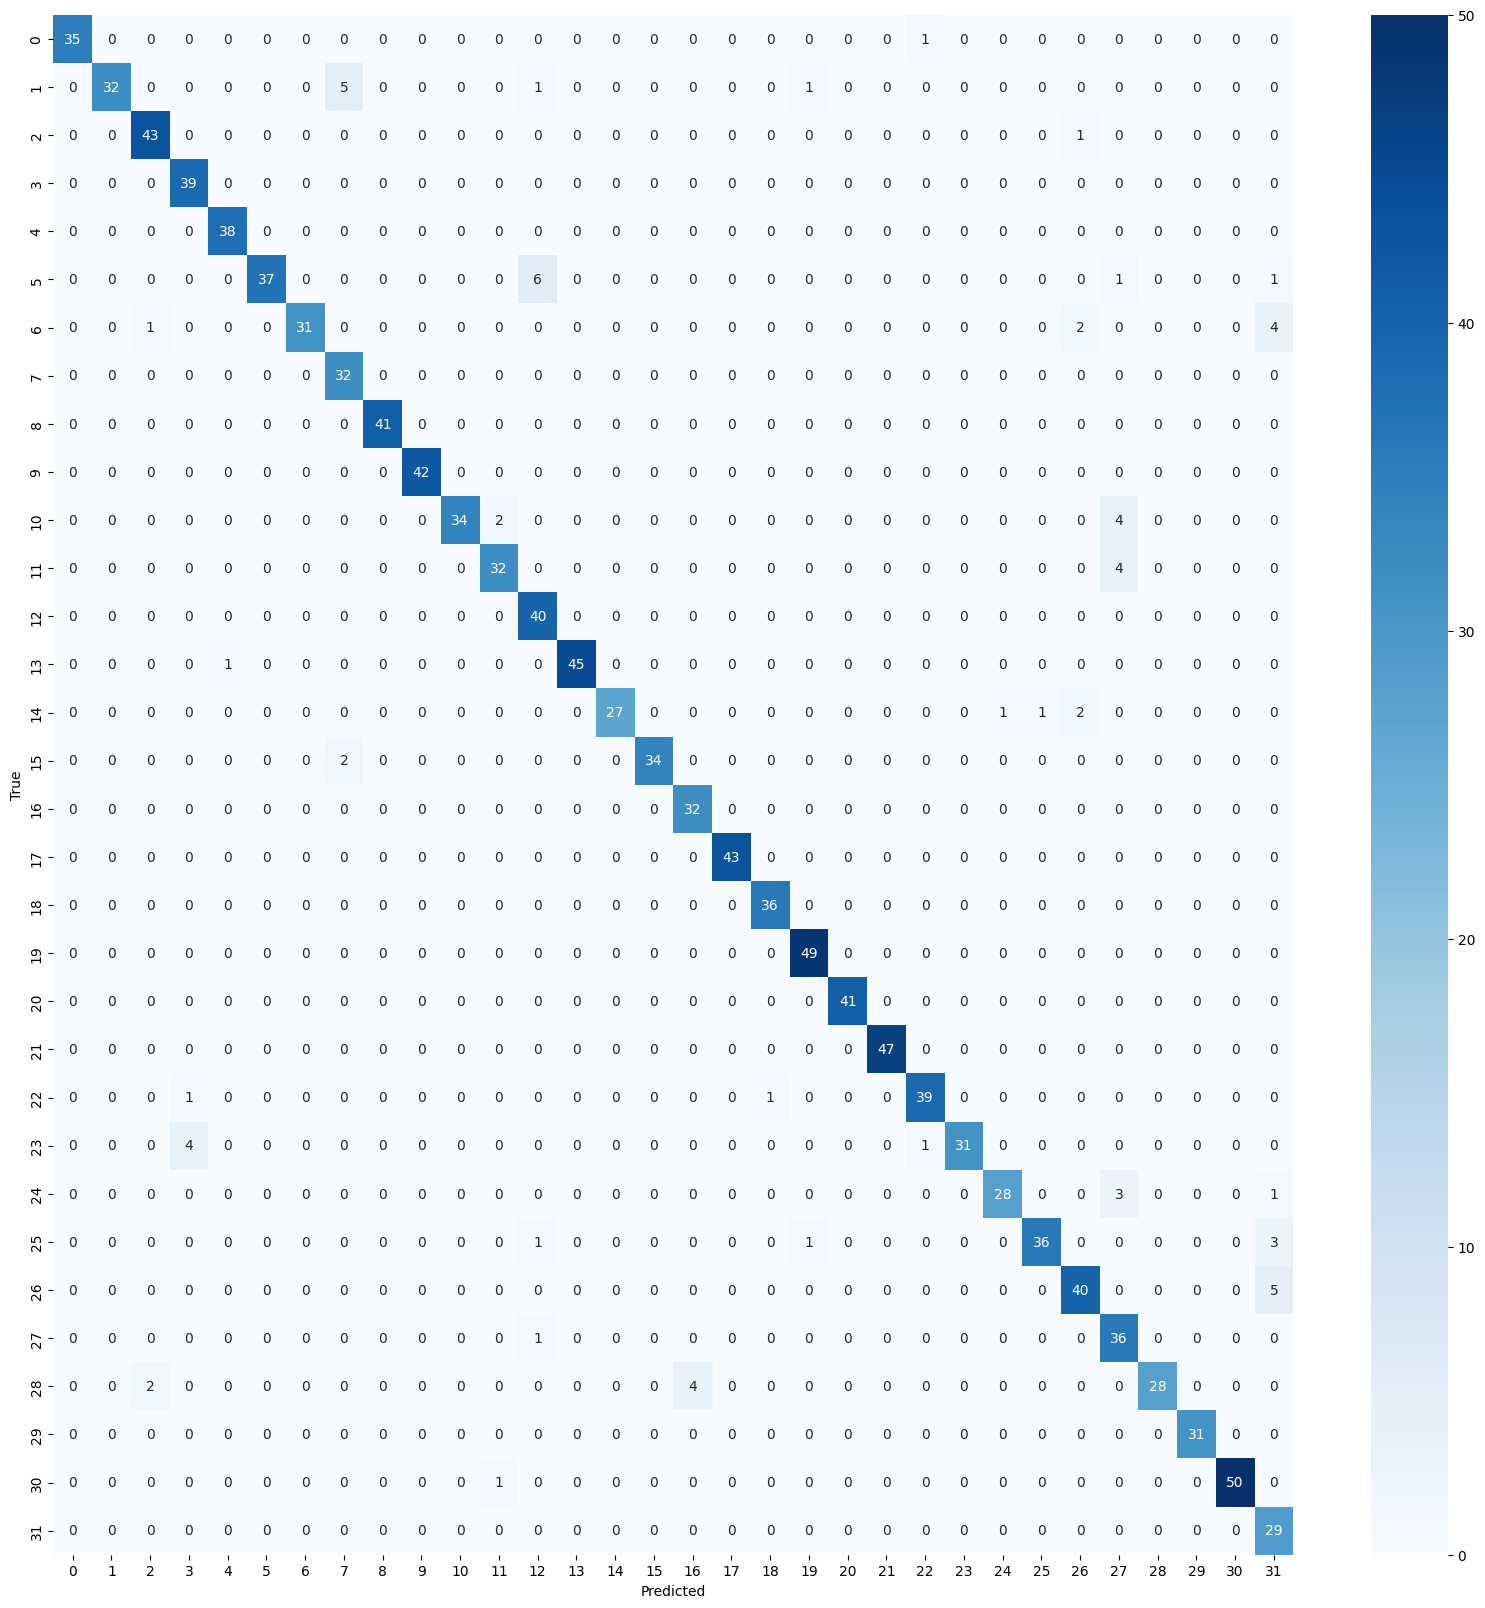

In [116]:
print("CNN")
model = GestureCNN(
    num_classes=33,
    d_model=84,
    d_hidden=64,
    dropout=0.3
)
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = CrossEntropyLoss()

example_input = torch.randn(16, 100, 84)
logits = model(example_input)

print(logits.shape)
train(
    model=model,
    epochs=30,
    optimizer=optimizer,
    loss_fn=loss_fn
)

testing_results = test(  
    model=model,
    loss_fn=loss_fn
)

print(f"Testing loss:\t\t{testing_results["test_loss"]}")
print(f"Testing accuracy:\t{testing_results["test_acc"]}")
print(f"Testing F1:\t\t{testing_results["f1_score"]}")

plt.figure(figsize=(20, 20))
sns.heatmap(testing_results["confusion_matrix"], annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()